In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
import warnings
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings("ignore")
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# pip install kagglehub

In [3]:
# this is way to direct import dataset by link

import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")

train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

train.head()

Using Colab cache for faster access to the 'ag-news-classification-dataset' dataset.


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [4]:
train = pd.read_csv(os.path.join(path, "train.csv"))
test = pd.read_csv(os.path.join(path, "test.csv"))

In [5]:
train.head(10)

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
5,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...
6,3,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...
7,3,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...
8,3,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...
9,3,Wall St. Bears Claw Back Into the Black,"NEW YORK (Reuters) - Short-sellers, Wall Stre..."


In [6]:
test.head(10)

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...
5,4,Open Letter Against British Copyright Indoctri...,The British Department for Education and Skill...
6,4,Loosing the War on Terrorism,"\\""Sven Jaschan, self-confessed author of the ..."
7,4,"FOAFKey: FOAF, PGP, Key Distribution, and Bloo...",\\FOAF/LOAF and bloom filters have a lot of i...
8,4,E-mail scam targets police chief,"Wiltshire Police warns about ""phishing"" after ..."
9,4,"Card fraud unit nets 36,000 cards","In its first two years, the UK's dedicated car..."


In [7]:
train.isnull().sum()

,0
Class Index,0
Title,0
Description,0


In [8]:
train.duplicated().sum()

np.int64(0)

In [9]:
test.isnull().sum()

,0
Class Index,0
Title,0
Description,0


CATAGORIAL MAPPING (NAMING)

In [10]:
category_map = {
    1:"World",
    2:"Sports",
    3:"Business",
    4:"Sci/Tech"
}

train["Category"] = train["Class Index"].map(category_map)
test["Category"] = test["Class Index"].map(category_map)

In [11]:
train.head(10)

,Class Index,Title,Description,Category
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business
5,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...,Business
6,3,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...,Business
7,3,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...,Business
8,3,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...,Business
9,3,Wall St. Bears Claw Back Into the Black,"NEW YORK (Reuters) - Short-sellers, Wall Stre...",Business


In [12]:
train['Category'].value_counts()

,count
Category,
Business,30000
Sci/Tech,30000
Sports,30000
World,30000


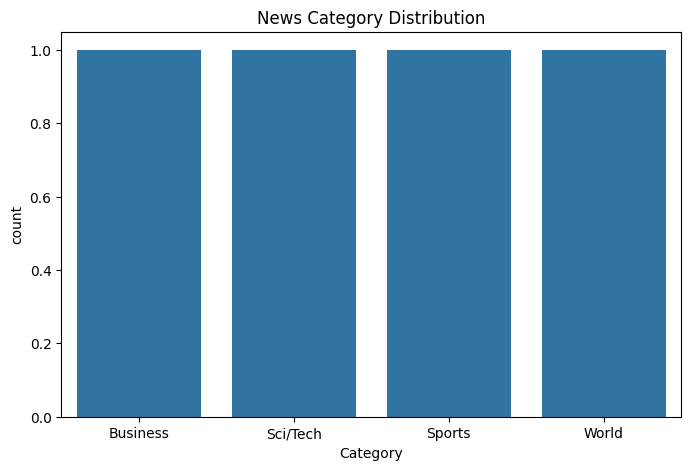

In [13]:
# plot category garph
plt.figure(figsize=(8,5))
sns.countplot(train['Category'].value_counts())
plt.title("News Category Distribution")
plt.show()

In [14]:
#Combine Title and Description

train['Text'] = train['Title'] + " " + train['Description']
test['Text'] = test['Title'] + " " + test['Description']

TEXT PREPROCESSING

In [15]:
ps = PorterStemmer()

def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [ps.stem(word) for word in words if word not in stopwords.words('english')]

    return " ".join(words)

Clean the data using this def or function

In [16]:
train['clean_text']= train['Text'].apply(preprocess)

In [17]:
test['clean_text']= test['Text'].apply(preprocess)

In [18]:
# TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

x_train = tfidf.fit_transform(train['clean_text']).toarray()
x_test = tfidf.transform(test['clean_text']).toarray()

TAEGET VALUE


In [19]:
y_train = train["Category"]
y_test = test["Category"]

TRAIN TEST MODEL

In [22]:
model = MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [23]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.8919736842105264


CONFUSION METRIX


In [24]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1600  200   23   77]
 [ 146 1646   27   81]
 [  11   18 1844   27]
 [  94   48   69 1689]]


In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Business       0.86      0.84      0.85      1900
    Sci/Tech       0.86      0.87      0.86      1900
      Sports       0.94      0.97      0.95      1900
       World       0.90      0.89      0.90      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



TESITING ON UNSEEN DATA

In [26]:
news = ["India defeated Australia in the cricket world cup by 7 wickets"]

news = tfidf.transform(news)

prediction = model.predict(news)

print("Prediction:", prediction[0])

Prediction: Sports
